In [390]:
import pandas as pd 


# Ratings 


ratings = pd.read_csv("C:/Users/oscwa/recommendation_system/data/ratings.csv", index_col = 0)
items = pd.read_csv("C:/Users/oscwa/recommendation_system/data/movies.csv", index_col = 0)
users =  pd.read_csv("C:/Users/oscwa/recommendation_system/data/users.csv", index_col = 0)

ratings = ratings[ratings["rating"] != 3]
# get time period of ratings 

print(users)

ratings["date"] = pd.to_datetime(ratings["timestamp"], unit = "s")
ratings["year"] = ratings["date"].dt.year

ratings = ratings.merge(users, right_on = "UserID", left_on = "userid", how = "inner")


ratings["Gender"] = [1 if i == "F" else 0 for i in ratings["Gender"]]
ratings["Age"] = (ratings["Age"] - ratings["Age"].mean()) / ratings["Age"].std()



 
ratings["rank"] = ratings.sort_values(["userid", "timestamp"]).groupby("userid").cumcount() + 1




ratings = pd.get_dummies(data = ratings, prefix= "Gender", columns = ["Gender"], dtype= int)



#ratings.sort_values(["userid", "timestamp"])

max_ranks = ratings.groupby("userid")["rank"].max().reset_index().rename(columns= {'rank': 'max_rank'})


ratings = ratings.merge(max_ranks, on = "userid")




ratings["is_val"] = (ratings["rank"] >= round(ratings["max_rank"]*0.8)).astype(int)

ratings["Zip-code"] = ratings["Zip-code"].str.replace("-", "")

ratings["Zip-code"] = ratings["Zip-code"].astype(int)

ratings["label"] = [1 if i > 2 else 0 for i in ratings["rating"]]




# keep only users with ≥ 1 positive rating
#pos_counts = ratings.groupby(["userid", "is_val"])["label"].sum().reset_index()




#test = pos_counts.groupby("userid")["label"].transform(lambda x: (x > 0).all())


#pos_counts[test]

cond = ratings[ratings["label"] == 1].groupby("userid")["is_val"].nunique() == 2

# We need to keep users that have atleast 1 positive rating in both train and val 

# Users that satisfy the condition
valid_users = cond[cond].index

# Filter dataframe
ratings = ratings[ratings["userid"].isin(valid_users)]



ratings["user_idx"] = ratings["userid"].astype("category").cat.codes
ratings["item_idx"] = ratings["movieid"].astype("category").cat.codes


train = ratings[ratings["is_val"] == 0]
val = ratings[ratings["is_val"] == 1]

      UserID Gender  Age  Occupation Zip-code
0          1      F    1          10    48067
1          2      M   56          16    70072
2          3      M   25          15    55117
3          4      M   45           7    02460
4          5      M   25          20    55455
...      ...    ...  ...         ...      ...
6035    6036      F   25          15    32603
6036    6037      F   45           1    76006
6037    6038      F   56           1    14706
6038    6039      F   45           0    01060
6039    6040      M   25           6    11106

[6040 rows x 5 columns]


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset, DataLoader
import torch 
from collections import defaultdict
import numpy as np 
import random 



#user_cat = ratings_filtered["userid"].astype("category")
#item_cat = ratings_filtered["movieid"].astype("category")

class userdataset(Dataset):
    def __init__(self, data, strong_neg_weight, weak_neg_weight, k, q, mode):
        self.data = data
        self.users = set(self.data["user_idx"])
        self.items = set(self.data["item_idx"])
        self.positive_by_user, self.negative_by_user = self.create_lookup()
        self.strong_neg_weight = strong_neg_weight
        self.weak_neg_weight = weak_neg_weight
        self.mode = mode
        self.k = k
        self.q = q
        self.dense_features = self.data[["Age", "Gender_0", "Gender_1"]].to_numpy()
        self.user_to_occupation = dict(zip(self.data["user_idx"], self.data["Occupation"]))
        self.user_to_zipcode = dict(zip(self.data["user_idx"], self.data["Zip-code"]))
        self.occupation_to_idx = {user: index for index, user in enumerate(self.data["Occupation"].unique())}
        self.zip_to_idx = {user: index for index, user in enumerate(self.data["Zip-code"].unique())}

    def sample_strong_negatives(self, negative_interactions, non_interactions):
         if negative_interactions:
            arr_len = len(negative_interactions)
            if arr_len >= 3:
                 items = random.sample(sorted(negative_interactions), 3)
                 return items, [self.strong_neg_weight] * len(items)           
            else:
                items_strong_neg =  random.sample(sorted(negative_interactions), arr_len)
                items_weak_neg, weights_weak_neg = self.sample_weak_negatives(non_interactions, 3 - arr_len)
                weights_strong_neg = [self.strong_neg_weight] * len(items_strong_neg)
             

                return items_strong_neg + items_weak_neg, weights_strong_neg + weights_weak_neg
           
         else:
          
           return self.sample_weak_negatives(non_interactions, 3)
         
    def sample_weak_negatives(self,user_non_interactions, samples):
            
            

            if samples >= len(user_non_interactions):
                items = list(user_non_interactions)
            else:            
                items = random.sample(sorted(user_non_interactions), samples)  

            return items, [self.weak_neg_weight] * len(items)
             
    def interactions_by_user(self, user_id):
        positive_interactions = self.positive_by_user[user_id]
        negative_interactions = self.negative_by_user[user_id]
        
        all_interactions = positive_interactions.union(negative_interactions)
        non_interactions =  self.items.difference(all_interactions)
        return non_interactions, negative_interactions, positive_interactions
    
    def features(self, userid):
        
          zip_feature = self.zip_to_idx[self.user_to_zipcode[userid]]
          occupation = self.occupation_to_idx[self.user_to_occupation[userid]]
          
         
          

          dense_feaures = self.dense_features[userid]
          return dense_feaures, zip_feature, occupation
    
    def sample_positive(self, user_id):
           try:
             test = np.random.choice(list(self.positive_by_user[user_id]))
             return test 
           except Exception as e:
               print(f"{user_id} does not exist")
         
    def create_lookup(self):
        
          users_positive_pairs = defaultdict(set) 
          users_negative_pairs = defaultdict(set)
     
        
          for row in self.data.itertuples(index= False):
            if row.rating > 2:
                users_positive_pairs[row.user_idx].add(row.item_idx)
            else:
                users_negative_pairs[row.user_idx].add(row.item_idx)
            

          return users_positive_pairs, users_negative_pairs
            
    def __len__(self):
        return len(self.users)   

        
          
    def __getitem__(self, user_id):


        non_interactions, negative_interactions, positive_interactions = self.interactions_by_user(user_id)

        if self.mode == "train":
           pos = self.sample_positive(user_id)
           negs_weak, negs_weak_weights = self.sample_weak_negatives(non_interactions, samples= self.k)
           negs_strong, negs_strong_weights = self.sample_strong_negatives(negative_interactions, non_interactions)

           negs = negs_weak + negs_strong
           weights = negs_weak_weights + negs_strong_weights
           
           dense, zip_feature, occupation_feature = self.features(user_id)

    

           return {"userid" :torch.tensor(user_id),
                "pos" : torch.tensor(pos), 
                "negs": torch.tensor(negs, dtype= torch.long), 
                "weights": torch.tensor(weights, dtype = torch.long),
                "dense" :torch.tensor(dense, dtype = torch.long),
                "occupation": torch.tensor(occupation_feature),
                "zip" : torch.tensor(zip_feature)
                 }
        if self.mode == "val":

            pos = list(positive_interactions)
            
            negs_weak= list(non_interactions)
            weights_weak = [self.weak_neg_weight] * len(negs_weak)
             
            negs = negs_weak + list(negative_interactions)

            weights = ([self.strong_neg_weight] * len(list(negative_interactions))) + weights_weak
            dense, zip_feature, occupation_feature = self.features(user_id)
            

            return {"userid" :torch.tensor(user_id),
                "pos" : torch.tensor(pos), 
                "negs": torch.tensor(negs, dtype= torch.long), 
                "weights": torch.tensor(weights, dtype = torch.long),
                "dense" :torch.tensor(dense, dtype = torch.long),
                "occupation": torch.tensor(occupation_feature),
                "zip" : torch.tensor(zip_feature)
                 }
            


    
import torch 
import torch.nn as nn


class TwoTowerModel(nn.Module):
    def __init__(self, user_dim, item_dim, embedd_dim, hidden_dim, ocupation_dim, zip_dim):
        super(TwoTowerModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.user_dim = user_dim
        self.item_dim = item_dim
        self.embedd_dim = embedd_dim
        self.ocupation_dim = ocupation_dim
        self.zip_dim = zip_dim

        self.ocupation_embedding = nn.Embedding(self.ocupation_dim, 24)
        self.zip_embedding = nn.Embedding(self.zip_dim, 24)
        self.item_embedding = nn.Embedding(self.item_dim, self.embedd_dim)  # 3000 x 512     x    
        self.user_embedding = nn.Embedding(self.user_dim, self.embedd_dim)
        
  
        self.usertower = torch.nn.Sequential(
            torch.nn.Linear(self.embedd_dim + 24 +  3 + 24, self.hidden_dim),
            torch.nn.LayerNorm(self.hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        #(1x131 and 128x64)

        self.itemtower = torch.nn.Sequential(
            torch.nn.Linear(self.embedd_dim, self.hidden_dim),
            torch.nn.LayerNorm(self.hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.ReLU(),
            torch.nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )



    
    def forward(self,batch):

    
        s_negative_embedding = self.item_embedding(batch["negs"])
        s_pos_embedding = self.item_embedding(batch["pos"])
        user_embedding = self.user_embedding(batch["userid"])
        user_dense = batch["dense"]
        try:
          user_zip_embedding = self.zip_embedding(batch["zip"])
        except Exception as e:
            
          print(f"{batch['zip']} did not exist in zip  embedding")   
        try:
          user_occupation_embedding = self.ocupation_embedding(batch["occupation"])
        except Exception as e: 
          print(batch["occupation"])  
          print(f"{batch['occupation']} did not exist in occupation embedding")    
          


        



        
      
        user_embedding = torch.cat([user_embedding,
                                    user_dense, 
                                    user_zip_embedding, 
                                    user_occupation_embedding], dim = 1
                                    ) # 1 x 307
        

        #print(user_embedding.shape)

        s_negative_embedding = self.itemtower(s_negative_embedding)

        #print(s_negative_embedding.shape)
        s_positive_embedding = self.itemtower(s_pos_embedding)

        #print(s_positive_embedding.shape)
        s_user_embedding = self.usertower(user_embedding)

        #print(s_user_embedding.shape)
      
     
        return s_negative_embedding, s_positive_embedding, s_user_embedding

        
        
     


In [ ]:
user_to_occupation = dict(zip(val["user_idx"], ratings["Occupation"]))
occupation_to_id = {user: index for index, user in enumerate(val["Occupation"].unique())}




<function __main__.val(dataloader, k, model)>

In [392]:




dataset_train = userdataset(train, strong_neg_weight=1, weak_neg_weight= 1, k = 20, q = 2, mode = "train" )
dataset_val = userdataset(train, strong_neg_weight=1, weak_neg_weight= 1, k = 20, q = 2, mode = "train" )
dataset_rank = userdataset(val, strong_neg_weight=1, weak_neg_weight= 1, k = 2, q = 2, mode = "val" )

item_dim = len(set(ratings["item_idx"]))
user_dim = len(set(ratings["user_idx"]))
occupation_dim = len(set(ratings["Occupation"]))
zip_dim = len(set(ratings["Zip-code"]))


model = TwoTowerModel(user_dim= user_dim, item_dim= item_dim, embedd_dim= 512, hidden_dim = 128, zip_dim= zip_dim, ocupation_dim= occupation_dim)


dataloader_train = DataLoader(dataset_train, batch_size= 64, shuffle= True, drop_last= True)
dataloader_val = DataLoader(dataset_val, batch_size= 64, drop_last= True, shuffle= True)
dataloader_rank = DataLoader(dataset_rank, batch_size= 1, drop_last= True)
#dataset_val = userdataset(val, strong_neg_weight=1, weak_neg_weight= 0.25, k = 2)

#dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, drop_last= True)
#dataloader_val = DataLoader(dataset_val, batch_size=32, shuffle=True, drop_last= True)

#u, pos, negs, weights = next(iter(dataloader_train))


#for u, pos, negs, weights in dataloader_train:
#        print(u, pos, negs, weights)
#        embedding_table.weight[pos]
        


#test = userdataset(train, strong_neg_weight=1, weak_neg_weight= 0.25, k = 2)

#test_again = test.ranking_function(1)


#print(u, pos, negs, weights)



#test.non_interactions(1)




In [646]:
import matplotlib.pyplot as plt 

groups = val.groupby("userid").nunique()["movieid"]


#val[ratings["rating"] > 2].groupby("userid").nunique()["movieid"].median()


len(set(val["movieid"]))

3477

In [233]:
#users = pd.read_csv("C:/Users/oscwa/recommendation_system/data/users.csv", index_col = 0)

#print(users)



    

#embedding_table = nn.Embedding(4000, 64)




#model.item_embedding(negs["dense"])

 
model.ocupation_embedding.weight.shape         

torch.Size([20, 24])

In [ ]:
import torch.nn.functional as F
import torch.optim as optim

class BPRLoss(nn.Module):
    def forward(self, user, neg, pos, weights, criterion):
          
            tau = 0.2

            s_pos = ((user * pos)/tau).sum(dim=-1).unsqueeze(1)
                     # [1]
            s_neg = ((user.unsqueeze(1) * neg)/tau).sum(dim=-1)
                      # [4]
            
            x = s_pos  - s_neg  

            loss_vec = F.softplus(-x)                # [4]
            loss = (loss_vec * weights).sum() / (weights.sum() + 1e-8)


            return loss 
        
 


def val(dataloader, k, model):

     mean_precision_by_user = []
     mean_recall_by_user = []
     for batch in dataloader:
          with torch.no_grad():

              neg, pos, user = model(batch)

              

              candidates = torch.cat([pos.squeeze(0), neg.squeeze(0)], dim=0)
              

              #user = F.normalize(user, dim=-1) 
              #candidates = F.normalize(candidates, dim =-1)
              scores = torch.matmul(user, candidates.T)/0.2

              

              labels = torch.cat([torch.ones(pos.shape[1]), torch.zeros(neg.shape[1])])
          
              topk_scores, topk_idx = torch.topk(scores, k, dim=1)   # (u_dim, k)
              topk_labels = labels[topk_idx] 
              recall_at_k = topk_labels.sum(dim = 1)/ labels.sum()
              precision_at_k = topk_labels.sum(dim=1) / k             # (u_dim,)
              mean_precision_at_k = precision_at_k.mean().item()
              mean_precision_by_user.append(mean_precision_at_k)
              mean_recall_by_user.append(recall_at_k)
     precision_at_k = sum(mean_precision_by_user) / len(mean_precision_by_user)
     recall_at_k = sum(recall_at_k) / len(recall_at_k)
     return precision_at_k, recall_at_k  

       

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
score = torch.nn.CosineSimilarity(dim = 1)
loss_fn = BPRLoss()
train_loss = []
val_loss = []
precisions = []
num_epochs = 30
for epoch in range(num_epochs):
        precision, recall = val(dataloader_rank, model = model, k = 10)
        precisions.append(precision)
        print(f"precision is {precision} and recall is {recall} at epoch {epoch}")
        running, nsteps = 0.0, 0
        for batch in dataloader_train:
                

                optimizer.zero_grad()
                neg, pos, user = model(batch)
                
                weight_vector = batch["weights"]


        
                loss = loss_fn(user, neg, pos, weight_vector, score)
                loss.backward()
                optimizer.step()

                running += loss.item()
                nsteps += 1
        total_loss = running / max(nsteps,1)
        train_loss.append(total_loss)
        print(f"epoch [{epoch+1}/{num_epochs}], loss: {total_loss:.6f}")
       
        running, nsteps = 0.0, 0
        with torch.no_grad():
              for batch in dataloader_val:
                    neg,pos,user = model(batch)
                    weight_vector = batch["weights"]
                    loss = loss_fn(user, neg, pos, weight_vector, score)
                    running += loss.item()
                    nsteps += 1

              total_loss = running / max(nsteps,1)
              val_loss.append(total_loss)
              print(f"epoch [{epoch+1}/{num_epochs}], #val_loss#: {total_loss:.6f}")

        








precision is 0.005160320719421587 and recall is 0.01785714365541935 at epoch 0
epoch [1/30], loss: 8.319319
epoch [1/30], #val_loss#: 3.958072
precision is 0.012675350897745762 and recall is 0.01785714365541935 at epoch 1
epoch [2/30], loss: 2.623833
epoch [2/30], #val_loss#: 1.649194
precision is 0.02226118940384729 and recall is 0.0 at epoch 2
epoch [3/30], loss: 1.304184
epoch [3/30], #val_loss#: 1.021538
precision is 0.025851703828117332 and recall is 0.01785714365541935 at epoch 3
epoch [4/30], loss: 0.912581
epoch [4/30], #val_loss#: 0.816209
precision is 0.027788911617013242 and recall is 0.01785714365541935 at epoch 4
epoch [5/30], loss: 0.752984
epoch [5/30], #val_loss#: 0.699668
precision is 0.029909820140960938 and recall is 0.0 at epoch 5
epoch [6/30], loss: 0.678543
epoch [6/30], #val_loss#: 0.633194
precision is 0.030193721279551684 and recall is 0.0 at epoch 6
epoch [7/30], loss: 0.630616
epoch [7/30], #val_loss#: 0.620028
precision is 0.031179025242915135 and recall is 

In [376]:

precisions




[0.005911823735387626,
 0.03208082886605599,
 0.03273213147475031,
 0.035136941145998524,
 0.032348029941330375]

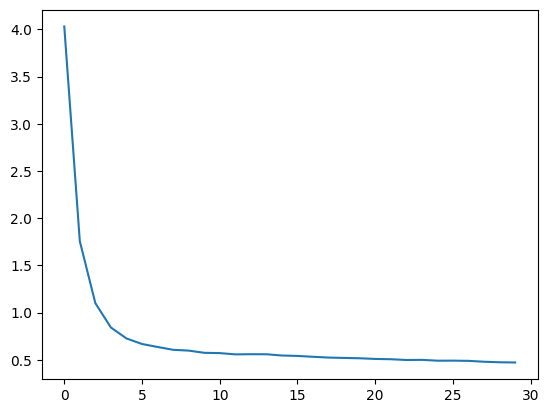

In [389]:
import matplotlib.pyplot as plt 

plt.plot(val_loss)

In [354]:
mean_precision_at_k

0.09687499701976776